# Task2 实践 1：卷积核

目标：在训练 CNN 之前，亲手把一张图拆成数字，再用卷积核处理它。

本步骤（第 2 小题）：用 Pillow 读入 highway.png，转 NumPy 数组和 PyTorch Tensor，
观察 shape、dtype、最大最小值和一个像素的 RGB，并理解 HWC 与 CHW 的区别。

第 1 小题（像素 / RGB / 灰度图 vs 彩色图）是概念题，先自己想，答案最后统一写进 note.md。

In [29]:
from PIL import Image
import numpy as np

img = Image.open("highway.png")
print("PIL 对象类型:", type(img))
print("size (宽, 高):", img.size)
print("mode:", img.mode)

PIL 对象类型: <class 'PIL.PngImagePlugin.PngImageFile'>
size (宽, 高): (960, 540)
mode: RGB


In [30]:
img_np = np.array(img)
print("shape:", img_np.shape)
print("dtype:", img_np.dtype)
print("最大值:", img_np.max(), "| 最小值:", img_np.min())
print("第 100 行第 200 列那个像素的 RGB:", img_np[100, 200])

shape: (540, 960, 3)
dtype: uint8
最大值: 255 | 最小值: 16
第 100 行第 200 列那个像素的 RGB: [127 169 207]


In [31]:
import torch

img_t = torch.from_numpy(img_np.copy())
print("Tensor shape (HWC):", img_t.shape, "| dtype:", img_t.dtype)

img_chw = img_t.permute(2, 0, 1)
print("permute 后 Tensor shape (CHW):", img_chw.shape)

Tensor shape (HWC): torch.Size([540, 960, 3]) | dtype: torch.uint8
permute 后 Tensor shape (CHW): torch.Size([3, 540, 960])


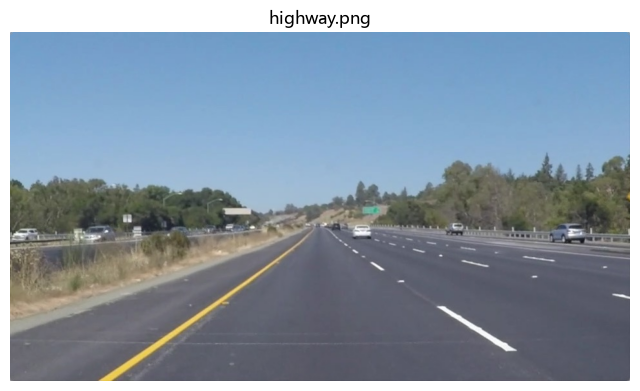

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.imshow(img_np)
plt.title("highway.png")
plt.axis("off")
plt.show()

In [33]:
import numpy as np

def conv2d(image, kernel):
    """对单通道灰度图做 valid 卷积（不带 padding，输出比输入小）"""
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k_h, j:j+k_w]
            out[i, j] = (patch * kernel).sum()
    return out


In [34]:
x = np.arange(9, dtype=np.float64).reshape(3, 3)
k = np.ones((2, 2))
print(conv2d(x, k))
print("应为 [[ 8. 12.]")
print("      [20. 24.]]")

rng = np.random.default_rng(0)
x = rng.random((5, 5))
ident = np.zeros((3, 3))
ident[1, 1] = 1.0
print(np.allclose(conv2d(x, ident), x[1:4, 1:4]))
print("上面这行应为 True（单位核 = 原样取出中间区域）")


[[ 8. 12.]
 [20. 24.]]
应为 [[ 8. 12.]
      [20. 24.]]
True
上面这行应为 True（单位核 = 原样取出中间区域）


In [35]:
def conv2d_rgb(image, kernel):
    """对 HWC 彩色图做卷积：R/G/B 三个通道各调一次灰度版，再叠回去"""
    out_h = image.shape[0] - kernel.shape[0] + 1
    out_w = image.shape[1] - kernel.shape[1] + 1
    out = np.zeros((out_h, out_w, image.shape[2]), dtype=np.float64)
    for c in range(image.shape[2]):
        out[:, :, c] = conv2d(image[:, :, c], kernel)
    return out


In [36]:
img_gray = img_np.mean(axis=2)
img_small = img_gray[::2, ::2]
print("灰度图:", img_gray.shape, "→ 缩小版:", img_small.shape)

mean3 = np.ones((3, 3)) / 9.0

gauss5 = np.array([[1, 4, 7, 4, 1],
                   [4, 16, 26, 16, 4],
                   [7, 26, 41, 26, 7],
                   [4, 16, 26, 16, 4],
                   [1, 4, 7, 4, 1]], dtype=np.float64)
gauss5 /= gauss5.sum()

sharpen = np.array([[ 0, -1,  0],
                    [-1,  5, -1],
                    [ 0, -1,  0]], dtype=np.float64)

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float64)


灰度图: (540, 960) → 缩小版: (270, 480)


均值模糊 3x3 完成，用时 0.5 秒
高斯模糊 5x5 完成，用时 0.4 秒
锐化 完成，用时 0.4 秒
Sobel-X 完成，用时 0.4 秒
Sobel-Y 完成，用时 0.4 秒


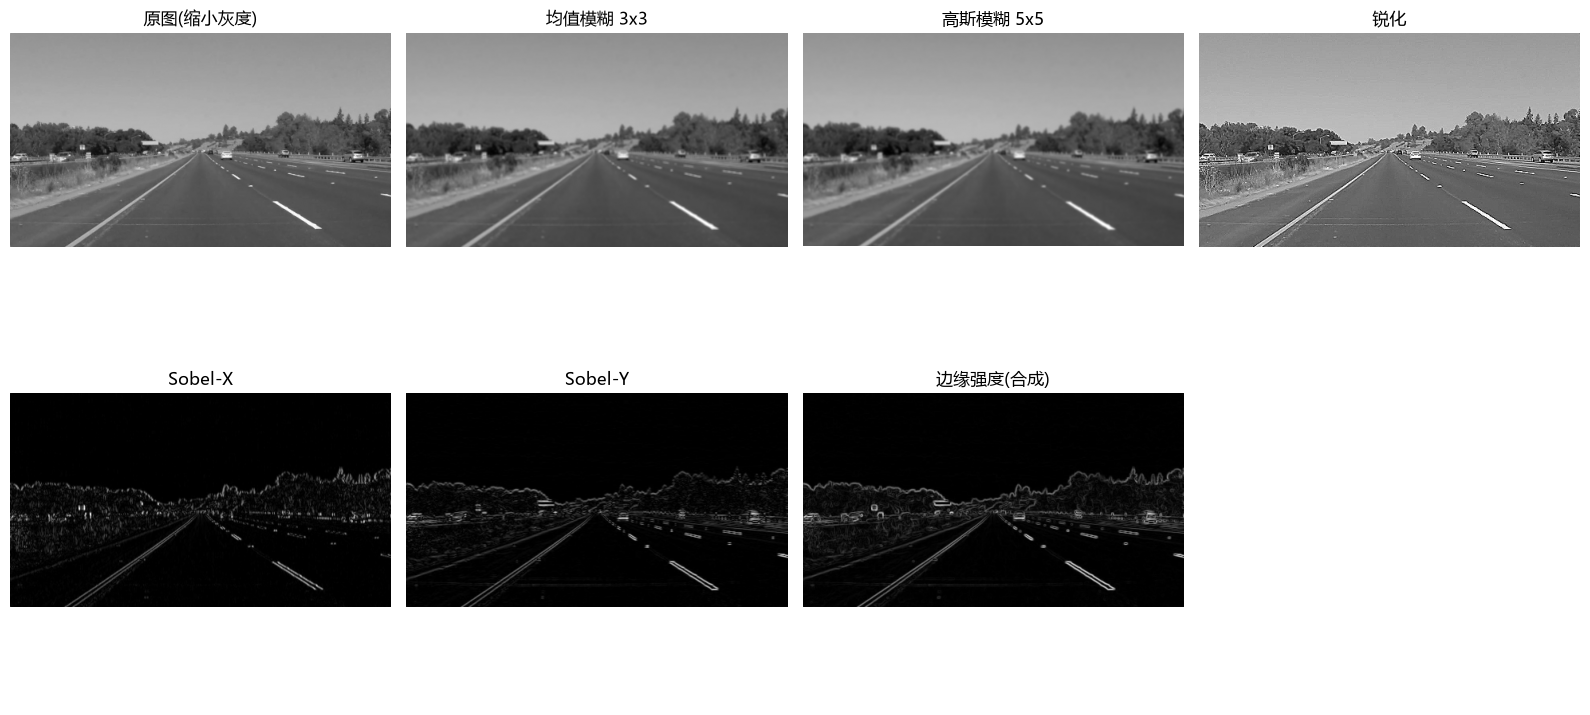

In [37]:
import time

results = {}
for name, k in [("均值模糊 3x3", mean3), ("高斯模糊 5x5", gauss5),
                ("锐化", sharpen), ("Sobel-X", sobel_x), ("Sobel-Y", sobel_y)]:
    t0 = time.time()
    results[name] = conv2d(img_small, k)
    print(name, "完成，用时", round(time.time() - t0, 1), "秒")

sobel_edge = np.sqrt(results["Sobel-X"] ** 2 + results["Sobel-Y"] ** 2)

titles = ["原图(缩小灰度)", "均值模糊 3x3", "高斯模糊 5x5", "锐化",
          "Sobel-X", "Sobel-Y", "边缘强度(合成)"]
imgs = [img_small,
        np.clip(results["均值模糊 3x3"], 0, 255),
        np.clip(results["高斯模糊 5x5"], 0, 255),
        np.clip(results["锐化"], 0, 255),
        np.abs(results["Sobel-X"]),
        np.abs(results["Sobel-Y"]),
        sobel_edge / sobel_edge.max()]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, im, title in zip(axes.flat, imgs, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
axes.flat[7].axis("off")
plt.tight_layout()
plt.show()


In [38]:
from matplotlib import font_manager

font_manager.fontManager.addfont("/mnt/c/Windows/Fonts/msyh.ttc")
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False
print("中文字体设置完成")


中文字体设置完成


In [39]:
def conv2d_pad(image, kernel, padding=0, stride=1):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    if padding > 0:
        image = np.pad(image, padding)
    img_h, img_w = image.shape
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)
    for i in range(out_h):
        for j in range(out_w):
            r, c = i * stride, j * stride
            patch = image[r:r+k_h, c:c+k_w]
            out[i, j] = (patch * kernel).sum()
    return out


In [40]:
for k_size, pad, stride in [(3, 0, 1), (3, 1, 1), (5, 2, 1), (3, 0, 2), (5, 2, 2)]:
    k = np.ones((k_size, k_size))
    out = conv2d_pad(img_small, k, padding=pad, stride=stride)
    h0, w0 = img_small.shape
    expect_h = (h0 + 2 * pad - k_size) // stride + 1
    expect_w = (w0 + 2 * pad - k_size) // stride + 1
    print(f"核 {k_size}x{k_size} padding={pad} stride={stride}"
          f" -> 输出 {out.shape}，公式算出 ({expect_h}, {expect_w})，"
          f"一致: {out.shape == (expect_h, expect_w)}")


核 3x3 padding=0 stride=1 -> 输出 (268, 478)，公式算出 (268, 478)，一致: True
核 3x3 padding=1 stride=1 -> 输出 (270, 480)，公式算出 (270, 480)，一致: True
核 5x5 padding=2 stride=1 -> 输出 (270, 480)，公式算出 (270, 480)，一致: True
核 3x3 padding=0 stride=2 -> 输出 (134, 239)，公式算出 (134, 239)，一致: True
核 5x5 padding=2 stride=2 -> 输出 (135, 240)，公式算出 (135, 240)，一致: True
